In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to generate energies and momenta of daughter particles from the dacay of a parent particle at rest
def decay_generator(M, m):
    # Generate energies and momenta
    E = E = M/2
    p_val = 0.5 * np.sqrt(M**2 - 4* m**2)

    cos_theta = np.random.uniform(-1, 1)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(0, 2*np.pi)

    px = p_val * np.sin(theta) * np.cos(phi)
    py = p_val * np.sin(theta) * np.sin(phi)
    pz = p_val * np.cos(theta)

    p1 = np.array([E, px, py, pz])
    p2 = np.array([E, -px, -py, -pz])

    return p1, p2

def invariant_mass(p1, p2):
    E = p1[0] + p2[0]
    px = p1[1] + p2[1]
    py = p1[2] + p2[2]
    pz = p1[3] + p2[3]

    return np.sqrt(E**2 - px**2 - py**2 - pz**2)

In [3]:
# Function to create N samples of invariant masses from the dacay of a particle of mass M at rest (without smearing)
def sample_M(M, m, N_samples):
    masses_sig = []
    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)
        inv_m = invariant_mass(p1, p2)
        masses_sig.append(inv_m)
    return masses_sig

In [4]:
#Function to create N samples of invariant masses from the decay of a particle of mass M at rest (with smearing)
def sample_M_smeared(M, m, N_samples, rel_sigma=0.03):
   
    masses_smear = []

    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)

        px1_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py1_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz1_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)
        px2_s = np.random.normal(p2[1], abs(p2[1]) * rel_sigma)
        py2_s = np.random.normal(p2[2], abs(p2[2]) * rel_sigma)
        pz2_s = np.random.normal(p2[3], abs(p2[3]) * rel_sigma)

        p1_smear = [_, px1_s, py1_s, pz1_s]
        p2_smear = [_, px2_s, py2_s, pz2_s]

        p_squared = p1_smear[1]**2 + p1_smear[2]**2 + p1_smear[3]**2
        E = np.sqrt(p_squared + m**2)
        p1_smear[0] = E
        p2_smear[0] = E

        inv_m = invariant_mass(p1_smear, p2_smear)
        masses_smear.append(inv_m)

    return masses_smear

In [5]:
# Function to create N samples of daughter particles momentum distribution from the decay of a particle of mass M at rest (without smearing)
def sample_p(M, m, N_samples):
    momentum_sig = []
    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)
        p_val = np.sqrt(p1[1]**2 + p1[2]**2 + p1[3]**2)
        momentum_sig.append(p_val)
    return momentum_sig

In [6]:
#Function to create N samples of daughter particles momentum distribution from the decay of a particle of mass M at rest (with smearing)
def sample_p_smeared(M, m, N_samples, rel_sigma=0.03):
   
    momentum_smear = []

    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)

        px_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)

        p_val_smear = np.sqrt(px_s**2 + py_s**2 + pz_s**2)
        momentum_smear.append(p_val_smear)
    return momentum_smear

In [7]:
# Function to create N samples of invariant masses from the two photon interaction with exponential mass distribution
def sample_exp(M_max, m, N_samples):
    masses_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)
        inv_m = invariant_mass(p1, p2)
        masses_bkg.append(inv_m)
    return masses_bkg

In [8]:
# Function to create N samples of daughter particles momentum distribution from the two photon interaction with exponential mass distribution
def sample_p_exp(M_max, m, N_samples):
    momentum_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)
        p_val = np.sqrt(p1[1]**2 + p1[2]**2 + p1[3]**2)
        momentum_bkg.append(p_val)
    return momentum_bkg

In [9]:
# Particle masses in [GeV]
particles = {
  "J/psi": 3.1,
  "p": 0.938,
  "mu": 0.105,
  "e" : 0.000511,
  "K_0" : 0.498,
  "K_+" : 0.494,
  "phi" : 1.019,
  "psip" : 3.686
}

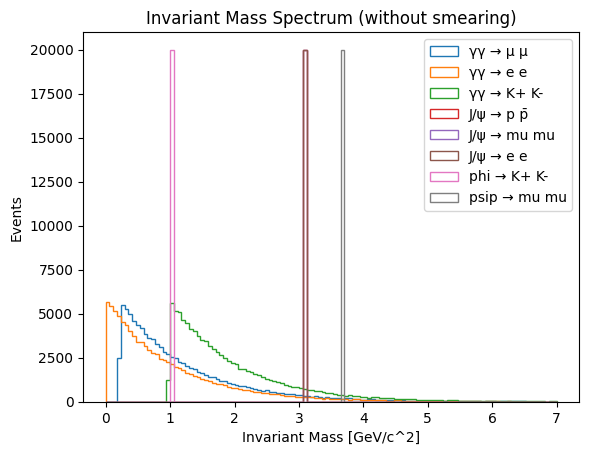

In [10]:
# Plot the combined invariant mass distribution for all cases (without smearing)
bins = np.linspace(0, 7, 120)

plt.hist(sample_exp(7, particles['mu'], 100000), bins=bins, histtype='step', label='γγ → μ μ')
plt.hist(sample_exp(7, particles['e'], 100000), bins=bins, histtype='step', label='γγ → e e')
plt.hist(sample_exp(7, particles['K_+'], 100000), bins=bins, histtype='step', label='γγ → K+ K-')

plt.hist(sample_M(particles['J/psi'], particles['p'], 20000), bins=bins, histtype='step', label='J/ψ → p p̄')
plt.hist(sample_M(particles['J/psi'], particles['mu'], 20000), bins=bins, histtype='step', label='J/ψ → mu mu')
plt.hist(sample_M(particles['J/psi'], particles['e'], 20000), bins=bins, histtype='step', label='J/ψ → e e')
plt.hist(sample_M(particles['phi'], particles['K_+'], 20000), bins=bins, histtype='step', label='phi → K+ K-')
plt.hist(sample_M(particles['psip'], particles['mu'], 20000), bins=bins, histtype='step', label='psip → mu mu')

plt.xlabel("Invariant Mass [GeV/c^2]")
plt.ylabel("Events")
plt.title("Invariant Mass Spectrum (without smearing)")
plt.legend()
plt.show()

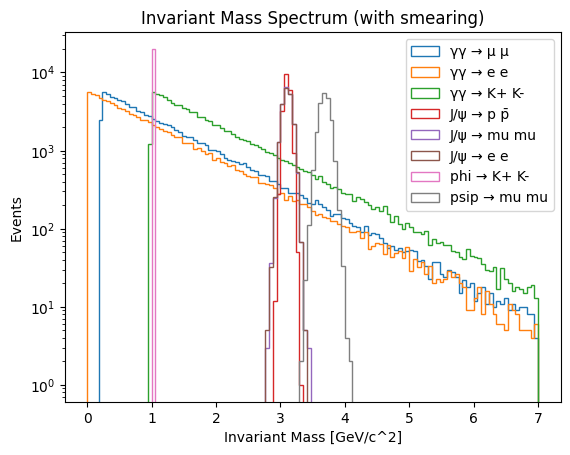

In [11]:
# Plot the combined invariant mass distribution for all cases (with smearing applied)
bins = np.linspace(0, 7, 120)

plt.hist(sample_exp(7, particles['mu'], 100000), bins=bins, histtype='step', label='γγ → μ μ')
plt.hist(sample_exp(7, particles['e'], 100000), bins=bins, histtype='step', label='γγ → e e')
plt.hist(sample_exp(7, particles['K_+'], 100000), bins=bins, histtype='step', label='γγ → K+ K-')

plt.hist(sample_M_smeared(particles['J/psi'], particles['p'], 20000), bins=bins, histtype='step', label='J/ψ → p p̄')
plt.hist(sample_M_smeared(particles['J/psi'], particles['mu'], 20000), bins=bins, histtype='step', label='J/ψ → mu mu')
plt.hist(sample_M_smeared(particles['J/psi'], particles['e'], 20000), bins=bins, histtype='step', label='J/ψ → e e')
plt.hist(sample_M_smeared(particles['phi'], particles['K_+'], 20000), bins=bins, histtype='step', label='phi → K+ K-')
plt.hist(sample_M_smeared(particles['psip'], particles['mu'], 20000), bins=bins, histtype='step', label='psip → mu mu')

plt.xlabel("Invariant Mass [GeV/c^2]")
plt.ylabel("Events")
plt.title("Invariant Mass Spectrum (with smearing)")
plt.yscale('log')
plt.legend()
plt.show()

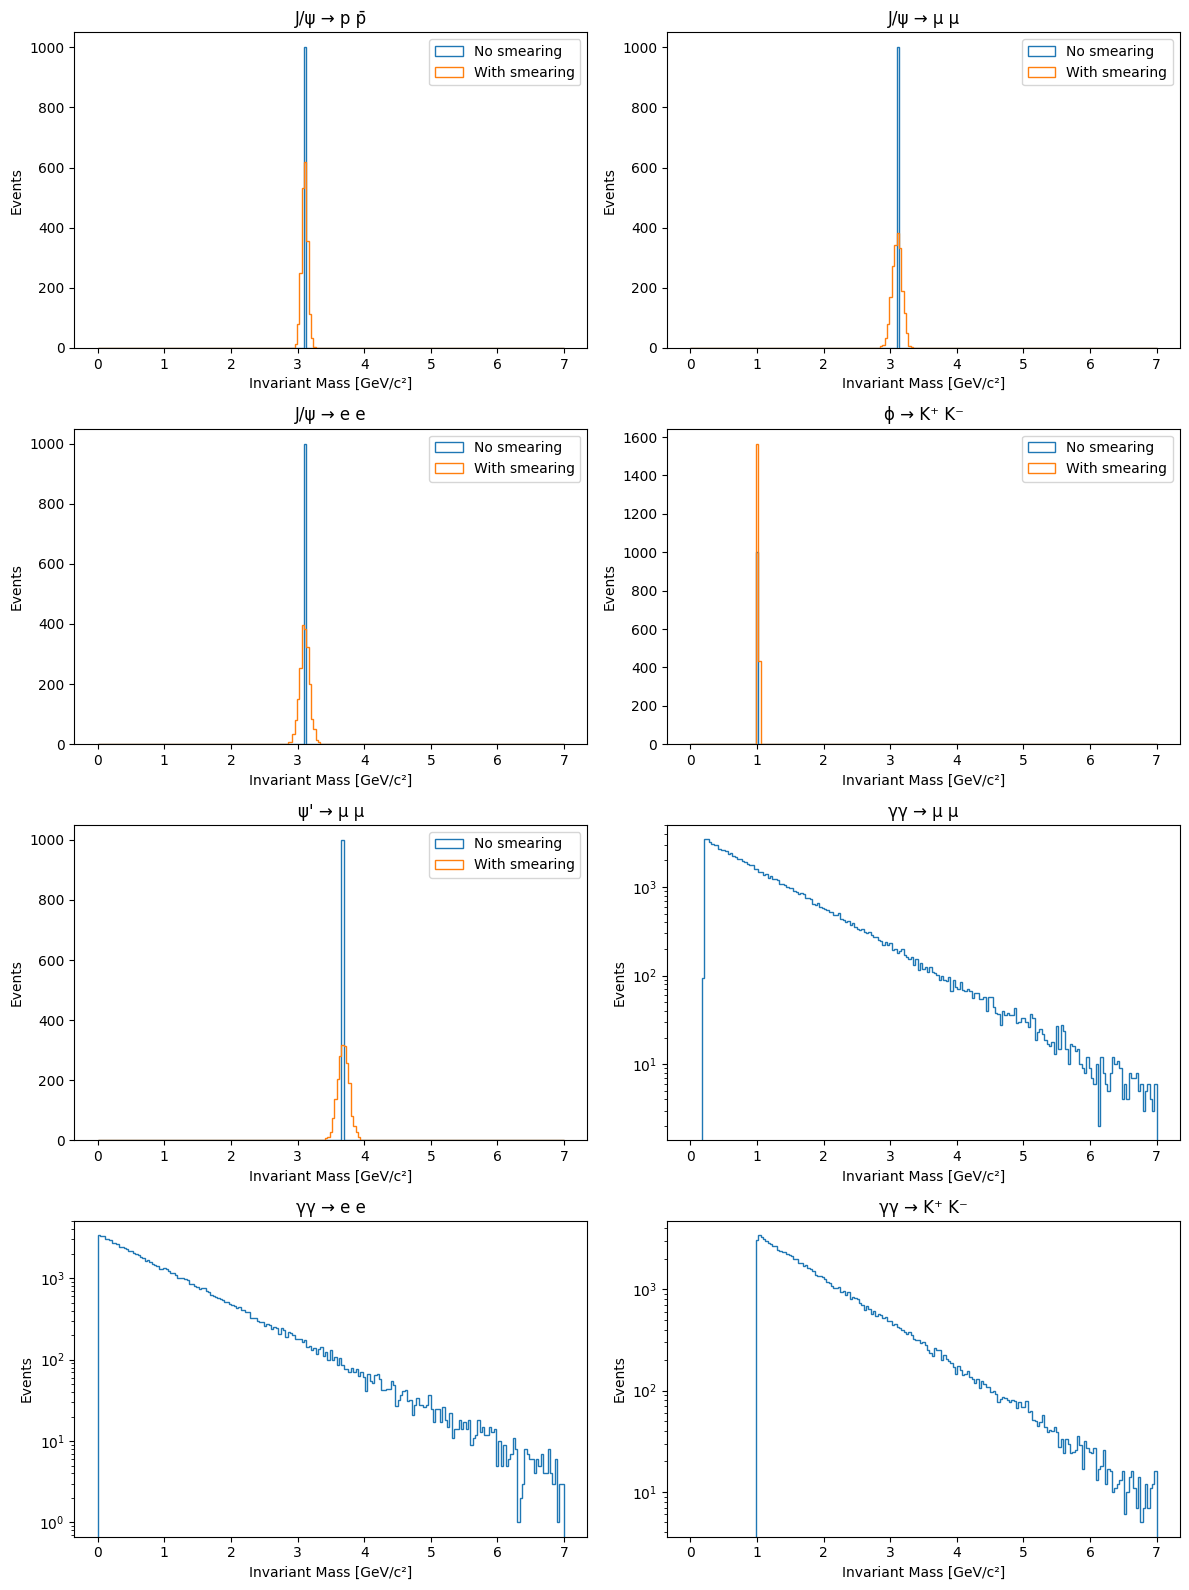

In [12]:
# Resonance reactions (with/without smearing)
resonances = [
    ("J/ψ → p p̄", particles['J/psi'], particles['p']),
    ("J/ψ → μ μ", particles['J/psi'], particles['mu']),
    ("J/ψ → e e", particles['J/psi'], particles['e']),
    ("ϕ → K⁺ K⁻", particles['phi'], particles['K_+']),
    ("ψ' → μ μ", particles['psip'], particles['mu']),
]

# Continuum γγ reactions (no smearing, log scale)
continuum = [
    ("γγ → μ μ", particles['mu']),
    ("γγ → e e", particles['e']),
    ("γγ → K⁺ K⁻", particles['K_+']),
]

bins = np.linspace(0, 7, 200)

# total number of plots
n = len(resonances) + len(continuum)

ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

i = 0

# First: resonance plots (overlay)
for label, M, m in resonances:
    
    masses_no = sample_M(M, m, 1000)
    masses_sm = sample_M_smeared(M, m, 2000, rel_sigma=0.03)
    
    ax = axes[i]
    ax.hist(masses_no, bins=bins, histtype='step', label='No smearing')
    ax.hist(masses_sm, bins=bins, histtype='step', label='With smearing')
    
    ax.set_title(label)
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel("Events")
    ax.legend()
    
    i += 1

# Then: γγ spectra (NO smearing, LOG scale)
for label, m in continuum:
    
    masses = sample_exp(7.0, m, 100000)
    
    ax = axes[i]
    ax.hist(masses, bins=bins, histtype='step')
    
    ax.set_title(label)
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel("Events")
    ax.set_yscale('log')
    
    i += 1

# Remove empty axes if any
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


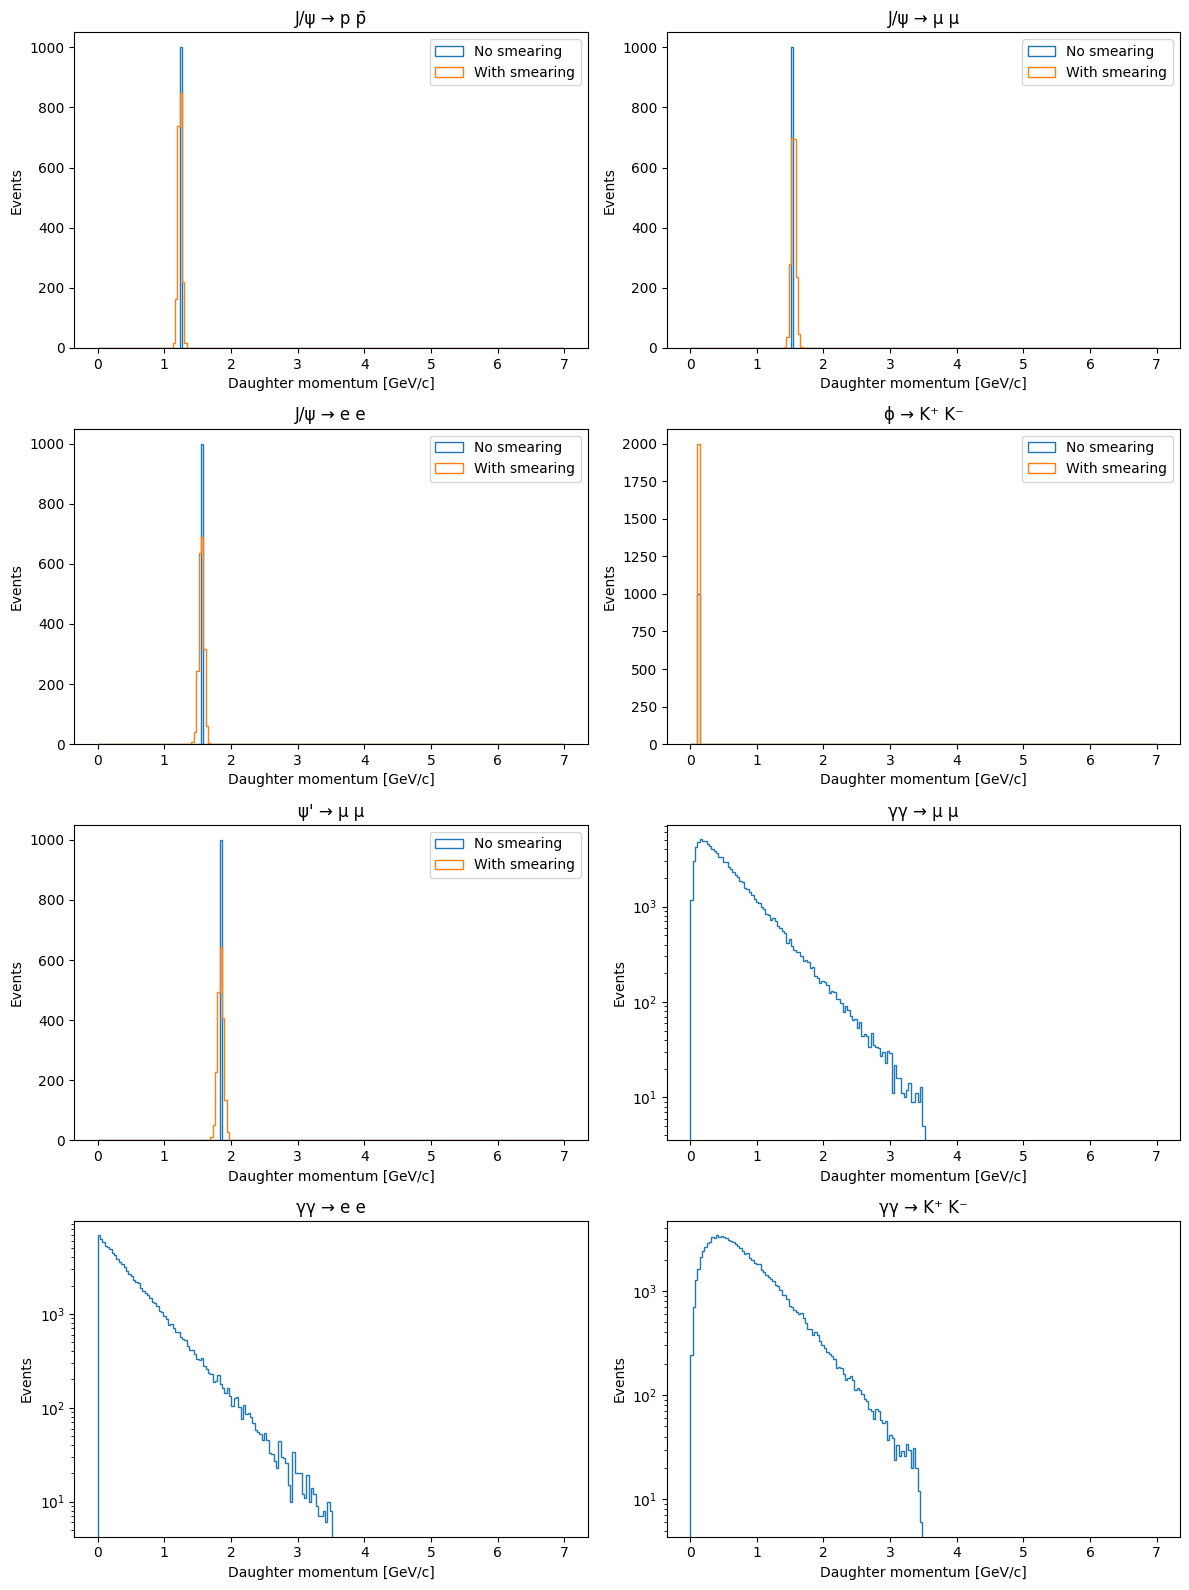

In [13]:
# total number of plots
n = len(resonances) + len(continuum)

ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

i = 0

# First: resonance plots (overlay)
for label, M, m in resonances:
    
    masses_no = sample_p(M, m, 1000)
    masses_sm = sample_p_smeared(M, m, 2000, rel_sigma=0.03)
    
    ax = axes[i]
    ax.hist(masses_no, bins=bins, histtype='step', label='No smearing')
    ax.hist(masses_sm, bins=bins, histtype='step', label='With smearing')
    
    ax.set_title(label)
    ax.set_xlabel("Daughter momentum [GeV/c]")
    ax.set_ylabel("Events")
    ax.legend()
    
    i += 1

# Then: γγ spectra (NO smearing, LOG scale)
for label, m in continuum:
    
    masses = sample_p_exp(7.0, m, 100000)
    
    ax = axes[i]
    ax.hist(masses, bins=bins, histtype='step')
    
    ax.set_title(label)
    ax.set_xlabel("Daughter momentum [GeV/c]")
    ax.set_ylabel("Events")
    ax.set_yscale('log')
    
    i += 1

# Remove empty axes if any
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# PID PLOT WITH BANDS

In [14]:
def bethe_bloch(momentum, mass, charge=1):
    # Constants for Bethe-Bloch approximation
    K = 0.307075 # MeV mol^-1 cm^2
    Z = charge # Particle charge
    I = 0.000016 # Mean excitation potential (MeV)
    m_e = 0.511 # Electron mass in MeV/c^2
    rho = 1 # Density of the material (relative to water, for simplicity)

    # Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    # Bethe-Bloch equation (simplified)
    dEdx = ((K * Z**2 * rho) / (beta**2) * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx

In [15]:
def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
        'electron': 0.000511,
        'muon': 0.10566,
        'pion': 0.13957,
        'kaon': 0.49367,
        'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass if not found
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3

    return dEdx, lower_band, upper_band

In [16]:
def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

In [17]:
def random_gaussian(mean, sigma):
    return np.random.normal(mean, sigma)

In [18]:
def gaussian_tpc_response(momentum, particle_type, stretch_factor):

    # Get the mean dE/dx from TPC PID response
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type,stretch_factor)

    # Calculate the extremes for the 3σ band
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)

    # Estimate σ as 1/3rd of the difference between the upper and lower bands
    sigma_dEdx = (upper_band - lower_band) / 6

    # Generate a random dE/dx value from a Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)

    return random_dEdx

In [19]:
# Example usage
momentum = .3 # Example momentum in GeV/c
particle_type = 'proton' # Example particle type
x=1000 #Amount of random numbers

rn=[]
for _ in range(x):

    if (particle_type == 'electron'):
        stretch_factor=1
    elif (particle_type == 'muon'):
        stretch_factor=.41
    elif (particle_type == 'pion'):
        stretch_factor=.41
    elif (particle_type == 'kaon'):
        stretch_factor=.38
    elif (particle_type == 'proton'):
        stretch_factor=.40

random_value = gaussian_tpc_response(momentum, particle_type, stretch_factor)
rn.append(random_value)

print(rn)

xvalues=[]
for _ in range(x):
    xvalues.append(momentum)
print(xvalues)

[261.98424298735915]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3

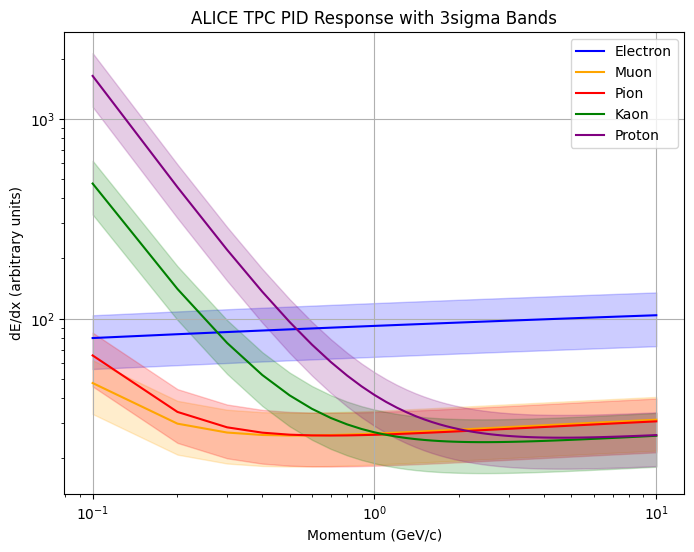

In [20]:
def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands for various particle types.
    """
    # Calculate responses and PID bands for different particle species
    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(8, 6))

    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)

momentum_range = np.linspace(0.1, 10, 100) # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)

# plt.plot(xvalues,rn, color= 'black')

plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.xscale('log')  # Log scale for x-axis
plt.yscale('log')  # Log scale for y-axis
plt.title('ALICE TPC PID Response with 3sigma Bands')
plt.legend()
plt.grid(True)
plt.show()


In [27]:
def plot_tpc_pid_response_points(momentum_range):
    
    plot_tpc_pid_response(momentum_range)

    # Resonance reactions
    resonances = [
        ("J/ψ → p p̄", particles['J/psi'], particles['p'], 'proton', 'purple', 0.4),
        ("J/ψ → μ μ", particles['J/psi'], particles['mu'], 'muon', 'orange', 0.41),
        ("J/ψ → e e", particles['J/psi'], particles['e'], 'electron', 'blue', 1),
        ("ϕ → K⁺ K⁻", particles['phi'], particles['K_+'], 'kaon', 'green', 0.28),
        ("ψ' → μ μ", particles['psip'], particles['mu'], 'muon', 'orange', 0.41),
    ]

    # Continuum γγ reactions
    continuum = [
        ("γγ → μ μ", particles['mu'], 'muon', 'orange', 0.41),
        ("γγ → e e", particles['e'], 'electron', 'blue', 1),
        ("γγ → K⁺ K⁻", particles['K_+'], 'kaon', 'green', 0.38),
    ]

    # 🔹 Generate momentum samples
    for reaction in continuum:
        momenta = sample_p_exp(7.0, reaction[1], 2000)
        momenta = np.array(momenta)
        dedx, low, high = tpc_pid_response(momenta, reaction[2], reaction[4])
        sigma = (high - low) / 6
        dedx_smeared = np.random.normal(dedx, sigma)
        plt.scatter(momenta, dedx_smeared, color=reaction[3], s=5, alpha=0.4)

    for reaction in resonances:
        momenta = sample_p_smeared(reaction[1], reaction[2], 2000)
        momenta = np.array(momenta)
        dedx, low, high = tpc_pid_response(momenta, reaction[3], reaction[5])
        sigma = (high - low) / 6
        dedx_smeared = np.random.normal(dedx, sigma)
        plt.scatter(momenta, dedx_smeared, color=reaction[4], s=5, alpha=0.4)

        
    # 🔹 Plot styling
    plt.xlabel('Momentum (GeV/c)')
    plt.ylabel('dE/dx (arbitrary units)')
    plt.xscale('log')
    plt.yscale('log')
    plt.title('ALICE TPC PID Response with Tracks')
    plt.xlim(0.1, 3)
    plt.ylim(0, 5000)
    plt.legend()
    plt.grid(True)

    plt.show()

/tmp/ipykernel_4401/3713592288.py:46: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 5000)


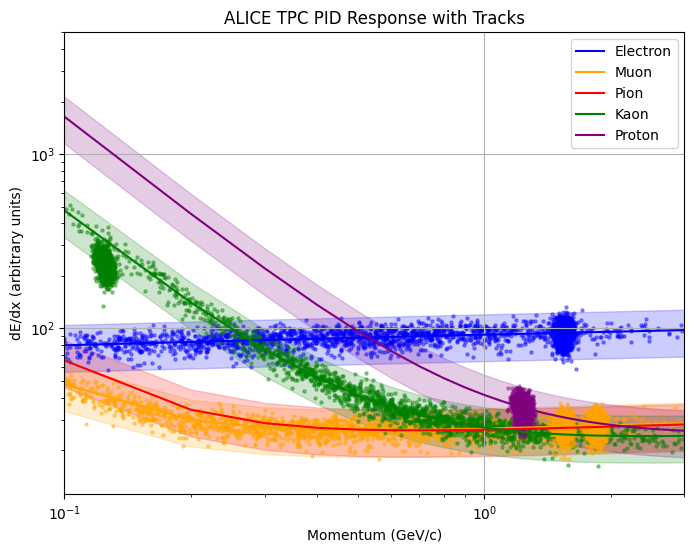

In [28]:
plot_tpc_pid_response_points(momentum_range)